# Session-Level PCA Population Analysis

This notebook demonstrates PCA analysis of MSN cell populations of a single session using the `Session` class.

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holoviews as hv
import hvplot.pandas
from pathlib import Path
from holoviews import opts
from bokeh.io import output_notebook
from bokeh.palettes import Plasma256
import sys

# Add parent directory to path to import Cell and PopulationAnalyzer
sys.path.append(str(Path.cwd()))

font_dict = {'title': 16, 'labels': 14, 'ticks': 12, 'legend': 12}
hv.opts.defaults(
    hv.opts.Curve(width=800, height=400, tools=['hover'], fontsize=font_dict),
    hv.opts.Image(width=800, height=600, tools=['hover'], cmap='Plasma', colorbar=True, fontsize=font_dict),
)

output_notebook()
hv.extension('bokeh')

print("Imports loaded successfully!")

Loading BokehJS ...

Imports loaded successfully!


In [147]:
# Load MSN cell database
monkey = 'fiona'  # 'yasmin' or 'fiona'

base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data' 
pickle_file = base_path / f'msn_{monkey}_cell_trial_data.pkl'

cell_df = pd.read_pickle(pickle_file)

In [148]:
# Add parent directory to path to import Cell and PopulationAnalyzer
sys.path.insert(0, str(Path.cwd().parent))
import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)
from session_class import Session
from cell_analysis import Cell, PopulationAnalyzer

print("Cell, PopulationAnalyzer, and Session classes imported successfully!")

Cell, PopulationAnalyzer, and Session classes imported successfully!


In [149]:
# Select a session to analyze - use session with most cells
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique().sort_values(ascending=False)
best_session_id = session_cell_counts.index[0]

print(f"Using session with most cells: {best_session_id}")
print(f"Number of cells in this session: {session_cell_counts.iloc[0]}")

# Get all data for this session
session_data = cell_df[cell_df['trial_session'] == best_session_id]

# Create Session object
session = Session(session_data, verbose=True)

Using session with most cells: fi211110a
Number of cells in this session: 85
Session fi211110a initialized:
  - Number of cells: 85
  - Total trials: 943
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]


In [150]:
session.drop_cells_with_missing_trial_type_or_dir_data()    

Cell 2134 removed from session fi211110a.
Dropped 1 cell(s) with incomplete trial type or directional data.


In [151]:
session

Session fi211110a | Cells: 84 | Trials: 943 | Trial Types: ['CONT', 'GO', 'STOP'] | Directions: [np.int64(0), np.int64(180)]

In [152]:
# for cell_id in session.cell_ids:
#     cell = Cell(session.get_cell_data(cell_id))
data = {
    'cell_ID': [],
    'baseline_FR': [],  
    'n_trials': []
}
for cell in session.cells:
    data['cell_ID'].append(cell.cell_id)
    data['baseline_FR'].append(cell.baseline_FR)
    data['n_trials'].append(len(cell.data))

fr_df = pd.DataFrame(data)
fr_df
fr_df.hvplot.hist('baseline_FR', bins=100, xlabel='Baseline Firing Rate (Hz)', 
                  ylabel='Count', title='Distribution of Baseline Firing Rates')


:Histogram   [baseline_FR]   (Count)

In [153]:
spike_data = session.get_population_spike_counts_data(
    epok=[-200, 500], bin_size=1,
    alignment_point='go_cue', trial_type='GO',
    direction=180, ssd_number=None,
    success_only=True, normalize=True,
    sort_by_peak=True
)

session.plot_population_spike_counts_heatmap(spike_data).opts(width=500, height=300)

:HeatMap   [columns,index]   (value)

In [154]:
res = session.get_population_PSTHs_left_right(
    epok=[-200, 500],
    bin_size=1,
    alignment_point='go_cue',
    trial_type='GO',
    success_only=True,
    smooth=True,
    smooth_ker_size=25, 
    delta=True,
    normalize_bins=False,
    normalize=True
)

In [155]:
(
    session.plot_population_PSTH_heatmap(res['left']).opts(width=500, height=300) + \
    session.plot_population_PSTH_heatmap(res['right']).opts(width=500, height=300)
).cols(2)

:Layout
   .HeatMap.I  :HeatMap   [columns,index]   (value)
   .HeatMap.II :HeatMap   [columns,index]   (value)

In [156]:
epok = [-200, 500]
left_right_for_PCA = session.get_population_PSTHs_left_right(
    epok=epok,
    bin_size=1,
    alignment_point='go_cue',
    trial_type='GO',
    success_only=True,
    smooth=True,
    smooth_ker_size=15, 
    delta=True,
    normalize_bins=False,
    normalize=False
)
left_right_for_PCA.keys()

dict_keys(['left', 'right', 'cell_order'])

In [157]:
left = left_right_for_PCA['left']['psth_matrix']
right = left_right_for_PCA['right']['psth_matrix']

left.shape, right.shape
psth_matrix = np.concatenate([left, right], axis=1)
psth_matrix.shape

(84, 1400)

In [158]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def pca_mat(mat, pca_components=5):
    scaler = StandardScaler()
    mat_for_pca = scaler.fit_transform(mat.T)
    pca = PCA(n_components=pca_components)
    pca.fit(mat_for_pca)
    return pca

pca = pca_mat(psth_matrix)
res = pca.transform(psth_matrix.T).T

In [159]:
pca.explained_variance_ratio_
cutoff = epok[1] - epok[0]
left_PCs = res[:, :cutoff]
right_PCs = res[:, cutoff:]
time = np.arange(epok[0], epok[1])

left_PCs.shape, right_PCs.shape, time.shape

((5, 700), (5, 700), (700,))

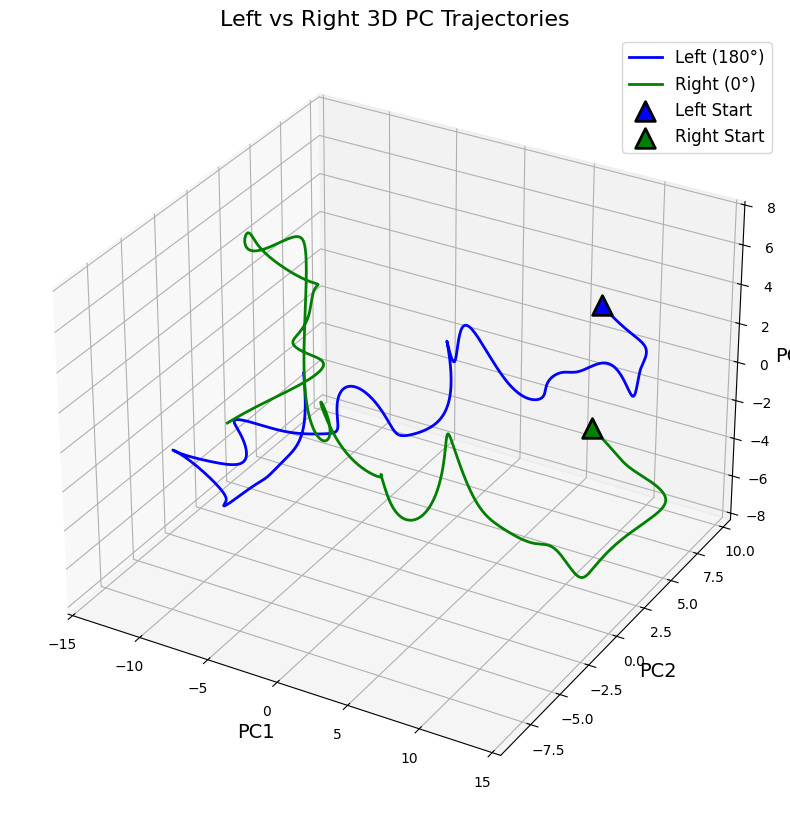

In [173]:
def plot_3D_PC_trajectories(left_PCs, right_PCs, time):
    # Create 3D plot using matplotlib
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot left trajectory (180°)
    ax.plot(left_PCs[0, :], left_PCs[1, :], left_PCs[2, :], 
        color='blue', linewidth=2, label='Left (180°)')

    # Plot right trajectory (0°)
    ax.plot(right_PCs[0, :], right_PCs[1, :], right_PCs[2, :], 
        color='green', linewidth=2, label='Right (0°)')

    # Mark start points with triangles
    ax.scatter(left_PCs[0, 0], left_PCs[1, 0], left_PCs[2, 0], 
        marker='^', s=200, color='blue', edgecolors='black', linewidths=2, 
        label='Left Start', zorder=5)

    ax.scatter(right_PCs[0, 0], right_PCs[1, 0], right_PCs[2, 0], 
        marker='^', s=200, color='green', edgecolors='black', linewidths=2, 
        label='Right Start', zorder=5)

    # Labels and title
    ax.set_xlabel('PC1', fontsize=14)
    ax.set_ylabel('PC2', fontsize=14)
    ax.set_zlabel('PC3', fontsize=14)
    ax.set_title('Left vs Right 3D PC Trajectories', fontsize=16)
    ax.legend(fontsize=12)
    
    return fig, ax

fig, ax = plot_3D_PC_trajectories(left_PCs, right_PCs, time)
plt.show()


In [174]:
train_session, test_session = session.split_to_train_test(
    test_fraction=0.5, random_state=42
)
train_session, test_session

(Session fi211110a | Cells: 84 | Trials: 943 | Trial Types: ['CONT', 'GO', 'STOP'] | Directions: [np.int64(0), np.int64(180)],
 Session fi211110a | Cells: 84 | Trials: 943 | Trial Types: ['CONT', 'GO', 'STOP'] | Directions: [np.int64(0), np.int64(180)])

In [175]:
epok=[-200, 500]
def get_data_patrix_for_PCA(session: Session, epok=[-200, 500]) -> np.ndarray:
    left_right_for_PCA = train_session.get_population_PSTHs_left_right(
        epok=epok,
        bin_size=1,
        alignment_point='go_cue',
        trial_type='GO',
        success_only=True,
        smooth=True,
        smooth_ker_size=15, 
        delta=True,
        normalize_bins=False,
        normalize=False
    )

    left = left_right_for_PCA['left']['psth_matrix']
    right = left_right_for_PCA['right']['psth_matrix']

    psth_matrix = np.concatenate([left, right], axis=1)
    return psth_matrix

pca = pca_mat(
    get_data_patrix_for_PCA(train_session, epok=epok)
)
res = pca.transform(
    get_data_patrix_for_PCA(test_session, epok=epok).T
).T

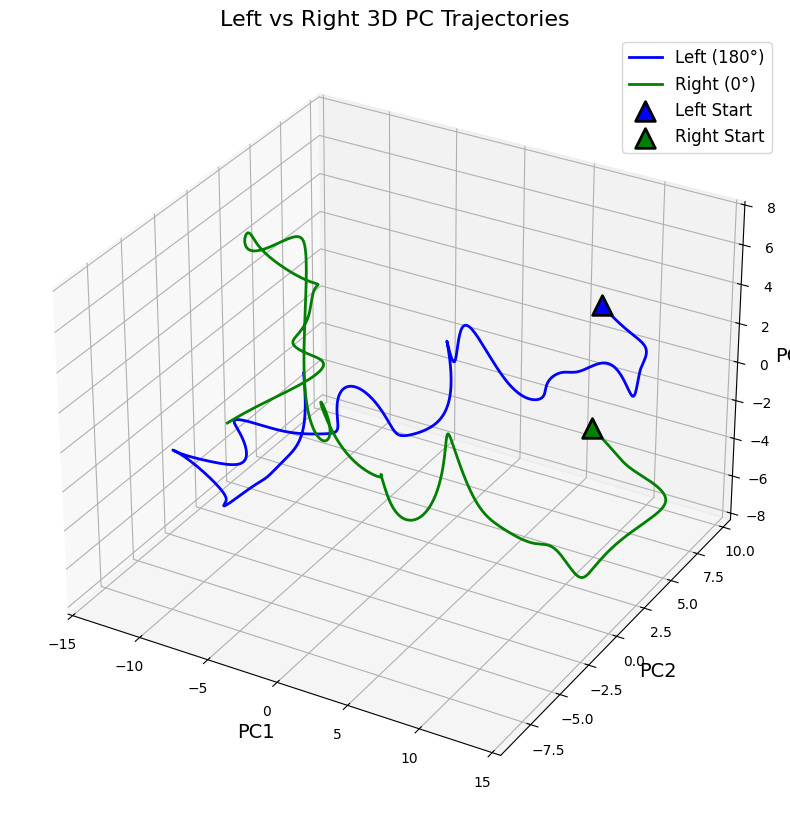

In [176]:
pca.explained_variance_ratio_
cutoff = epok[1] - epok[0]
left_PCs = res[:, :cutoff]
right_PCs = res[:, cutoff:]
time = np.arange(epok[0], epok[1])

left_PCs.shape, right_PCs.shape, time.shape
fig, ax = plot_3D_PC_trajectories(left_PCs, right_PCs, time)
plt.show()

In [186]:
epok = [-200, 500]
left_right_for_PCA = test_session.get_population_PSTHs_left_right(
    epok=epok,
    bin_size=1,
    alignment_point='go_cue',
    trial_type='CONT',
    success_only=True,
    smooth=True,
    smooth_ker_size=25, 
    delta=True,
    normalize_bins=False,
    normalize=False
)
left_right_for_PCA.keys()

left = left_right_for_PCA['left']['psth_matrix']
right = left_right_for_PCA['right']['psth_matrix']

stop_psth_matrix = np.concatenate([left, right], axis=1)

stop_res = pca.transform(stop_psth_matrix.T).T
stop_res.shape
stop_left_PCs = stop_res[:, :cutoff]
stop_right_PCs = stop_res[:, cutoff:]
stop_res.shape, stop_left_PCs.shape, stop_right_PCs.shape

((5, 1400), (5, 700), (5, 700))

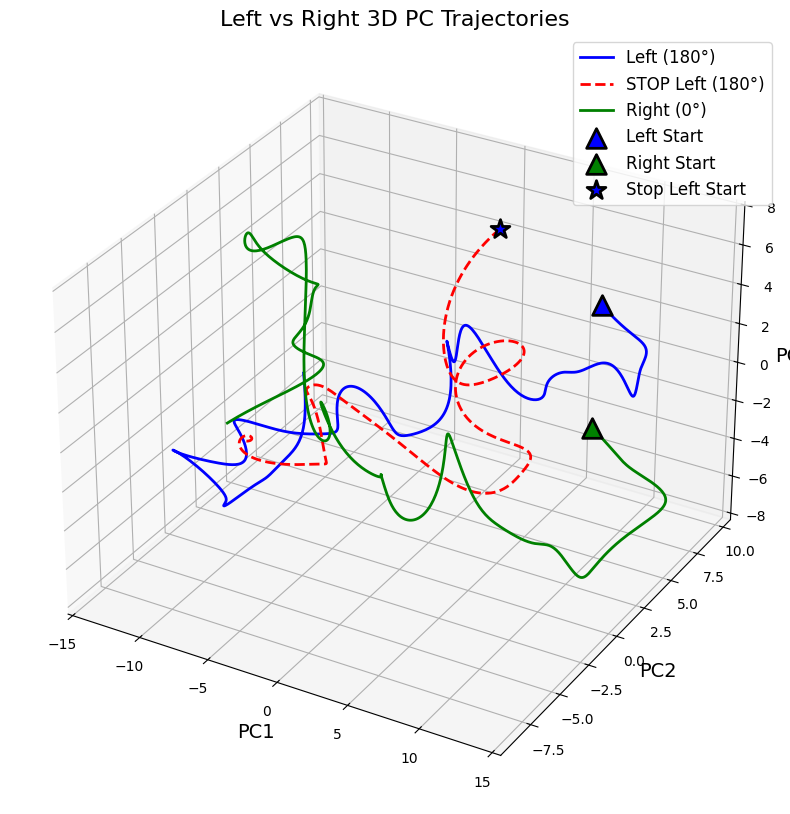

In [190]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
# ax = fig.add_subplot(111)

# Plot left trajectory (180°)
ax.plot(left_PCs[0, :], left_PCs[1, :], left_PCs[2, :], 
    color='blue', linewidth=2, label='Left (180°)')

# Plot left STOP trajectory (180°)
ax.plot(stop_left_PCs[0, :], stop_left_PCs[1, :], stop_left_PCs[2, :], 
    color='red', linewidth=2, label='STOP Left (180°)', linestyle='dashed')

# Plot right trajectory (0°)
ax.plot(right_PCs[0, :], right_PCs[1, :], right_PCs[2, :], 
    color='green', linewidth=2, label='Right (0°)')

# Plot right STOP trajectory (0°)
# ax.plot(stop_right_PCs[0, :], stop_right_PCs[1, :], #stop_right_PCs[2, :], 
#     color='yellow', linewidth=2, label='STOP Right (0°)', linestyle='dashed')

# Mark start points with triangles
ax.scatter(left_PCs[0, 0], left_PCs[1, 0], left_PCs[2, 0], 
    marker='^', s=200, color='blue', edgecolors='black', linewidths=2, 
    label='Left Start', zorder=5)

ax.scatter(right_PCs[0, 0], right_PCs[1, 0], right_PCs[2, 0], 
    marker='^', s=200, color='green', edgecolors='black', linewidths=2, 
    label='Right Start', zorder=5)

ax.scatter(stop_left_PCs[0, 0], stop_left_PCs[1, 0], stop_left_PCs[2, 0], 
    marker='*', s=200, color='blue', edgecolors='black', linewidths=2, 
    label='Stop Left Start', zorder=5)

# ax.scatter(stop_right_PCs[0, 0], stop_right_PCs[1, 0], #stop_right_PCs[2, 0], 
#     marker='*', s=200, color='green', edgecolors='black', linewidths=2, 
#     label='Stop Right Start', zorder=5)


# Labels and title
ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
ax.set_zlabel('PC3', fontsize=14)
ax.set_title('Left vs Right 3D PC Trajectories', fontsize=16)
ax.legend(fontsize=12)

